# Notebook Finance AI - Asistente Inteligente de Salud Financiera

## Librerias necesarias

In [251]:
import pandas as pd
import numpy as np
# import seaborn as sns
import matplotlib.pyplot as plt
# import requests
# import json
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold,cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as imbpipeline
from imblearn.over_sampling import SMOTE

Obtención de datos 

## Proceso ETL

In [ ]:
url = 'https://raw.githubusercontent.com/No-Country-simulation/G9-LATAM-Team71/refs/heads/develop/data-science/csv_prueba_modelo.csv' 
data = pd.read_csv(url)

data = data.drop(index=761)
data.info()

<class 'pandas.DataFrame'>
Index: 1157 entries, 0 to 1157
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   descripcion  1157 non-null   str    
 1   categoria    1157 non-null   str    
 2   tipo         1157 non-null   str    
 3   cualidad     1157 non-null   str    
 4   monto        1157 non-null   float64
 5   fecha        1157 non-null   str    
dtypes: float64(1), str(5)
memory usage: 63.3 KB


Separacion de variables, la variable a predecir (y) es la categoria que representa la descripción

In [253]:
y_categoria = data.categoria
X_categoria = data.descripcion
X_cualidad = data.descripcion
y_cualidad = data.cualidad

Grupo de palabras que se usan para delimitar la oración, y quedan fuera de nuestra lista

In [254]:
stop_words = [
    "de",
    "del",
    "la",
    "las",
    "el",
    "los",
    "en",
    "con",
    "para",
    "por",
    "y"
]

In [255]:
# funcion para dividir datos
def split_variables(X,y):
    X,X_test,y,y_test = train_test_split(X,y,stratify = y,random_state=5,test_size=0.15)#stratify indica que si hay un 10% de una variable, entonces ese 10 % tambien lo ponga en la division
    X_train,X_val,y_train,y_val = train_test_split(X,y,stratify = y,random_state=5) #x de entrenamiento
    return X,X_test,X_train, X_val,y,y_test, y_train, y_val

X_categoria, X_categoria_test,X_categoria_train, X_categoria_val, y_categoria, y_categoria_test, y_categoria_train,y_categoria_val = split_variables(X_categoria,y_categoria) # datos de entrenamiento para categoria

X_cualidad, X_cualidad_test,X_cualidad_train, X_cualidad_val, y_cualidad, y_cualidad_test, y_cualidad_train, y_cualidad_val = split_variables(X_cualidad,y_cualidad)   #datos de entrenamiento para cualidad


skf = StratifiedKFold(n_splits = 5,shuffle = True,random_state = 5)

In [256]:
# funcion prueba modelo
# metricas
metrics = ['accuracy','recall_macro','f1_macro']


def probar_modelo(X,y, modelo, balanceo = None):
  pipeline = imbpipeline([('vectorizacion',TfidfVectorizer(stop_words=stop_words)),('balanceo',balanceo),('modelo',modelo)])

  cv_resultados = cross_validate(pipeline,X,y,cv=skf,scoring=metrics)
  return cv_resultados


# funcion ejecutar modelo
def entrenar_modelo(modelo, balanceo = None):
  pipeline = imbpipeline([('vectorizacion',TfidfVectorizer(stop_words=stop_words)),('balanceo',balanceo),('modelo',modelo)])

  return pipeline

## Modelos a probar

* Logistic Regression
* Random Forest
* Linear SVC

### Logistic Regression

Es un modelo parecido a *Linear Regression* con la diferencia de que este modelo predice a partir de categorías y no de números como lo hace la regresión lineal

In [257]:
#categoria
mod_categoria_regresion_normal = probar_modelo(X_categoria,y_categoria,LogisticRegression());
mod_categoria_regresion_balanceado = probar_modelo(X_categoria,y_categoria,LogisticRegression(),SMOTE());

#cualidad
mod_cualidad_regresion_normal = probar_modelo(X_cualidad,y_cualidad,LogisticRegression());
mod_cualidad_regresion_balanceado = probar_modelo(X_cualidad,y_cualidad,LogisticRegression(),SMOTE());

pd.DataFrame({
    "Regresion lineal categoria":pd.DataFrame(mod_categoria_regresion_normal).mean(),
    "Regresion lineal categoria balanceada":pd.DataFrame(mod_categoria_regresion_balanceado).mean(),
    "Regresion lineal cualidad":pd.DataFrame(mod_categoria_regresion_normal).mean(),
    "Regresion lineal cualidad balanceada":pd.DataFrame(mod_categoria_regresion_balanceado).mean()
}).T

,fit_time,score_time,test_accuracy,test_recall_macro,test_f1_macro
Regresion lineal categoria,0.058899,0.010030,0.708003,0.571699,0.645137
Regresion lineal categoria balanceada,0.091790,0.008119,0.798550,0.733230,0.761428
Regresion lineal cualidad,0.058899,0.010030,0.708003,0.571699,0.645137
Regresion lineal cualidad balanceada,0.091790,0.008119,0.798550,0.733230,0.761428


### Random Forest

In [ ]:


mod_categoria_forest = probar_modelo(X_categoria,y_categoria,RandomForestClassifier(max_depth=5));
mod_categoria_forest_balanceado = probar_modelo(X_categoria,y_categoria,RandomForestClassifier(max_depth=5),SMOTE());

#cualidad
mod_cualidad_forest_normal = probar_modelo(X_cualidad,y_cualidad,RandomForestClassifier(max_depth=5));
mod_cualidad_forest_balanceado = probar_modelo(X_cualidad,y_cualidad,RandomForestClassifier(max_depth=5),SMOTE());


pd.DataFrame({
    "Modelo Forest categoria":pd.DataFrame(mod_categoria_forest).mean(),
    "Modelo Forest categoria balanceado":pd.DataFrame(mod_categoria_forest_balanceado).mean(),
    "Modelo Forest cualidad":pd.DataFrame(mod_cualidad_forest_normal).mean(),
    "Modelo Forest cualidad balanceado":pd.DataFrame(mod_cualidad_forest_balanceado).mean()
}).T

,fit_time,score_time,test_accuracy,test_recall_macro,test_f1_macro
Modelo Forest categoria,0.149235,0.017038,0.431332,0.193681,0.190678
Modelo Forest categoria balanceado,0.192375,0.024888,0.663270,0.546474,0.588602
Modelo Forest cualidad,0.131474,0.015016,0.898286,0.372710,0.380879
Modelo Forest cualidad balanceado,0.141519,0.014361,0.930851,0.828483,0.813059


### Linear SVC

In [ ]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
mod_categoria_LinearSVC_normal = probar_modelo(X_categoria,y_categoria,LinearSVC());
mod_categoria_LinearSVC_balanceado = probar_modelo(X_categoria,y_categoria,LinearSVC(),SMOTE());

#cualidad
mod_cualidad_LinearSVC_normal = probar_modelo(X_cualidad,y_cualidad,LinearSVC());
mod_cualidad_LinearSVC_balanceado = probar_modelo(X_cualidad,y_cualidad,LinearSVC(),SMOTE());

pd.DataFrame({
    "Modelo LinearSVC categoria":pd.DataFrame(mod_categoria_LinearSVC_normal).mean(),
    "Modelo LinearSVC categoria balanceado":pd.DataFrame(mod_categoria_LinearSVC_balanceado).mean(),
    "Modelo LinearSVC cualidad":pd.DataFrame(mod_cualidad_LinearSVC_normal).mean(),
    "Modelo LinearSVC cualidad balanceado":pd.DataFrame(mod_cualidad_LinearSVC_balanceado).mean()
}).T

,fit_time,score_time,test_accuracy,test_recall_macro,test_f1_macro
Modelo LinearSVC categoria,0.015140,0.007926,0.811763,0.743963,0.775027
Modelo LinearSVC categoria balanceado,0.059068,0.007701,0.803647,0.738937,0.762770
Modelo LinearSVC cualidad,0.009402,0.007952,0.957303,0.776341,0.811337
Modelo LinearSVC cualidad balanceado,0.022930,0.007715,0.938983,0.837926,0.800069


## Comparación de modelos y modelo elegido

In [260]:
pd.DataFrame({
    "Regresion lineal categoria balanceada":pd.DataFrame(mod_categoria_regresion_balanceado).mean(),
    "Regresion lineal cualidad balanceada":pd.DataFrame(mod_categoria_regresion_balanceado).mean(),
    "Modelo Forest categoria balanceado":pd.DataFrame(mod_categoria_forest_balanceado).mean(),
    "Modelo Forest cualidad balanceado":pd.DataFrame(mod_cualidad_forest_balanceado).mean(),
    "Modelo LinearSVC categoria balanceado":pd.DataFrame(mod_categoria_LinearSVC_balanceado).mean(),
    "Modelo LinearSVC cualidad balanceado":pd.DataFrame(mod_cualidad_LinearSVC_balanceado).mean()
}).T

,fit_time,score_time,test_accuracy,test_recall_macro,test_f1_macro
Regresion lineal categoria balanceada,0.091790,0.008119,0.798550,0.733230,0.761428
Regresion lineal cualidad balanceada,0.091790,0.008119,0.798550,0.733230,0.761428
Modelo Forest categoria balanceado,0.192375,0.024888,0.663270,0.546474,0.588602
Modelo Forest cualidad balanceado,0.141519,0.014361,0.930851,0.828483,0.813059
Modelo LinearSVC categoria balanceado,0.059068,0.007701,0.803647,0.738937,0.762770
Modelo LinearSVC cualidad balanceado,0.022930,0.007715,0.938983,0.837926,0.800069


El modelo con valores mas altos en *recall*, *accuracy* y *f1* fue el **Linear SVC** balanceado, por lo que ese será el modelo a tomar y con el que se obtendrán algunas métricas

### Prueba de modelo 

              precision    recall  f1-score   support

alimentacion       0.85      0.94      0.89        67
      deudas       1.00      1.00      1.00         8
   educacion       0.90      0.75      0.82        12
     ingreso       0.89      1.00      0.94         8
        ocio       0.90      0.50      0.64        18
       salud       1.00      0.54      0.70        13
   servicios       0.80      0.84      0.82        19
  transporte       0.85      0.85      0.85        20
    vivienda       0.56      1.00      0.72         9

    accuracy                           0.84       174
   macro avg       0.86      0.82      0.82       174
weighted avg       0.86      0.84      0.83       174



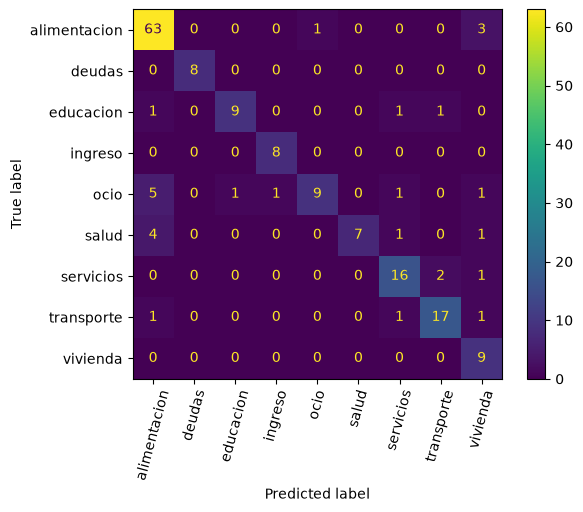

In [261]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report


modelo_categoria_svm = entrenar_modelo(LinearSVC(),SMOTE())
modelo_categoria_svm.fit(X_categoria_train, y_categoria_train)



y_pred = modelo_categoria_svm.predict(X_categoria_test)
print(classification_report(y_categoria_test,y_pred))
ConfusionMatrixDisplay.from_predictions(y_categoria_test,y_pred,xticks_rotation=75);

               precision    recall  f1-score   support

fijo_no_vital       1.00      1.00      1.00         4
   fijo_vital       0.73      0.69      0.71        16
     variable       0.97      0.97      0.97       154

     accuracy                           0.95       174
    macro avg       0.90      0.89      0.89       174
 weighted avg       0.95      0.95      0.95       174



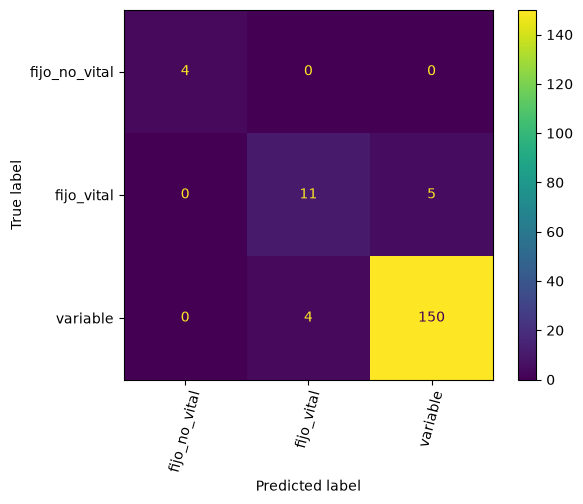

In [262]:
modelo_cualidad_svm = entrenar_modelo(LinearSVC(),SMOTE())
modelo_cualidad_svm.fit(X_cualidad_train,y_cualidad_train)

y_pred = modelo_cualidad_svm.predict(X_cualidad_test)
print(classification_report(y_cualidad_test,y_pred))
ConfusionMatrixDisplay.from_predictions(y_cualidad_test,y_pred,xticks_rotation=75);

In [263]:
import pickle
try:
  with open('models/categoria_champion.pkl','wb') as file:
    pickle.dump(modelo_categoria_svm,file)

  with open('models/cualidad_champion.pkl','wb') as file:
    pickle.dump(modelo_cualidad_svm,file)
   

except exception as e:
  print('Se presento error al realizar el modelo')